## **Linear Regression Model Implementation Using Python Library**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42)
exp = np.random.randint(1, 40, 300)
salary = 4 + 1.8 * exp + np.random.normal(0, 10, 300)
salary = np.clip(salary, 2, None)
salary = np.round(salary, 2)
df = pd.DataFrame({
    "Experience": exp,
    "Salary": salary
})

In [ ]:
df.head()


,Experience,Salary
0,39,64.94
1,29,51.07
2,15,38.10
3,8,19.32
4,21,48.10


In [ ]:
df.shape

(300, 2)

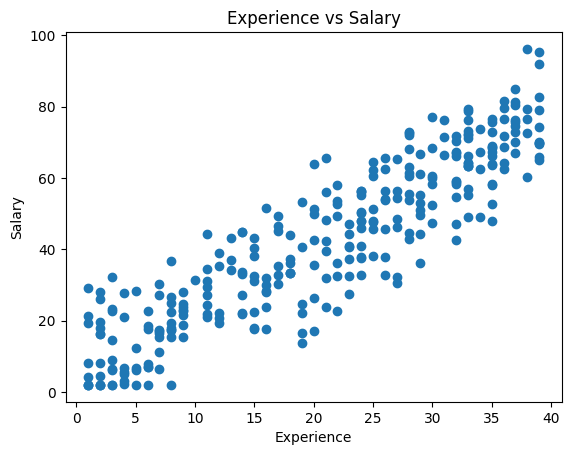

In [ ]:

plt.scatter(exp, salary)
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.show()

In [ ]:
X=df.iloc[:,0:1]
Y=df.iloc[:,-1]
Y


,Salary
0,64.94
1,51.07
2,38.10
3,19.32
4,48.10
...,...
295,63.37
296,65.54
297,71.75
298,40.99


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,Y_train)

LinearRegression()

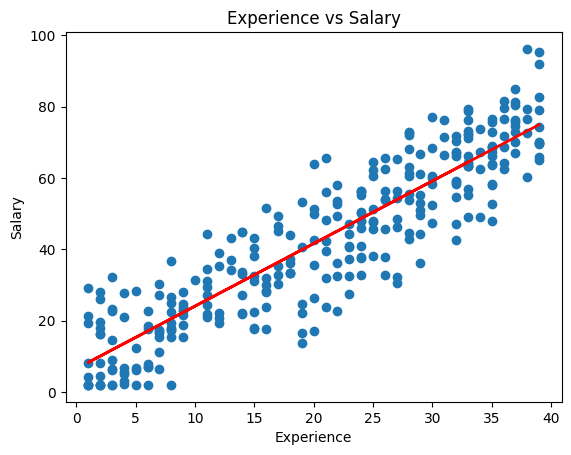

In [ ]:

plt.scatter(exp, salary)
plt.plot(X,lr.predict(X),color='red',linewidth=2)
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.show()

[1.7530126] 6.544829651851046


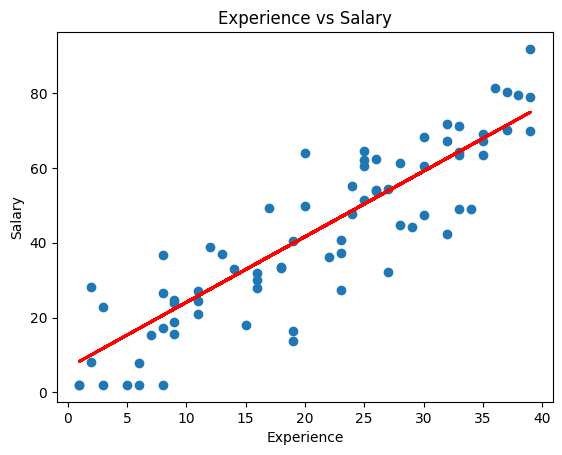

In [ ]:
m=lr.coef_
c=lr.intercept_
print(m,c)
plt.scatter(X_test,Y_test)
plt.plot(X_test,m*X_test+c,color='red',linewidth=2)
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
mse = mean_squared_error(Y, lr.predict(X))
r2 = r2_score(Y,lr.predict(X))
mae=mean_absolute_error(Y,lr.predict(X))
print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

MAE: 7.965305826368823
MSE: 96.80516552529998
R² Score: 0.8140217292861668


In [ ]:
#Adjusted R2 score
r2adj=1-(1-r2)*(len(Y)-1)/(len(Y)-X.shape[1]-1)
print("Adjusted R2 Score:",r2adj)

Adjusted R2 Score: 0.8133976411294089


LinearRegression()

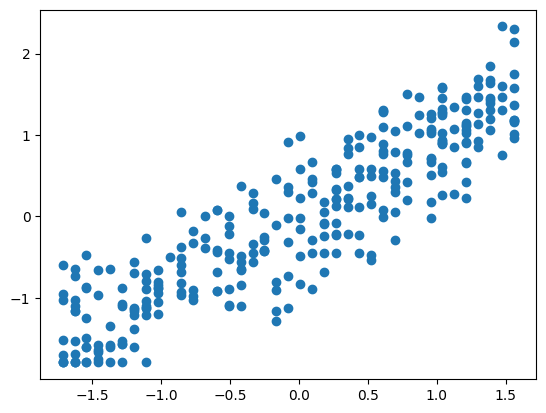

In [ ]:
X_sc=(X-np.mean(X))/np.std(X, axis=0)
Y_sc=(Y-np.mean(Y))/np.std(Y, axis=0)
plt.scatter(X_sc,Y_sc)
from sklearn.model_selection import train_test_split
Xsc_train,Xsc_test,Ysc_train,Ysc_test=train_test_split(X_sc,Y_sc,test_size=0.25,random_state=42)
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(Xsc_train,Ysc_train)

[0.89243741] 0.013624584199758117


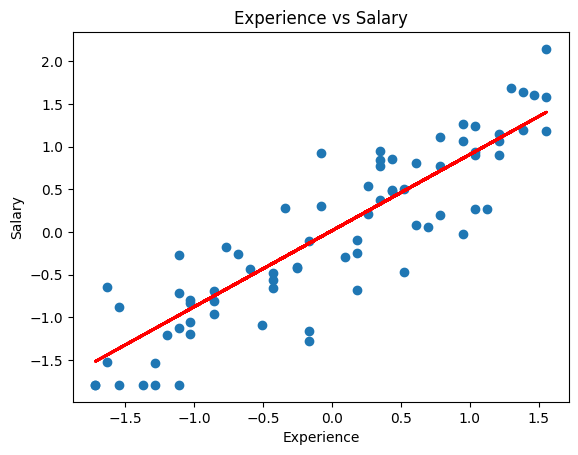

In [ ]:
m=lr.coef_
c=lr.intercept_
print(m,c)
plt.scatter(Xsc_test,Ysc_test)
plt.plot(Xsc_test,m*Xsc_test+c,color='red',linewidth=2)
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
mse = mean_squared_error(Y_sc, lr.predict(X_sc))
r2 = r2_score(Y_sc,lr.predict(X_sc))
mae=mean_absolute_error(Y_sc,lr.predict(X_sc))
print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

MAE: 0.3491276874536216
MSE: 0.18597827071383322
R² Score: 0.8140217292861668
